# تجميد الطبقات

In [49]:
def predict_all_images(Model, directory_path='.'):
    # 1. تعريف التحويلات
    transform = transforms.Compose([
        transforms.Resize((448, 448)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    # 2. حصر ملفات الصور
    valid_extensions = ('.jpg', '.jpeg', '.png', '.gif', '.bmp', '.webp', '.tif')
    image_files = [f for f in os.listdir(directory_path) 
                   if f.lower().endswith(valid_extensions)]

    if not image_files:
        print(f"❌ لم يتم العثور على صور في المجلد: {directory_path}")
        return

    # إنشاء عداد للفئات
    class_names = ['Invoice', 'Menu', 'Others']
    stats = {name: 0 for name in class_names}  
    errors = 0

    print(f"🚀 تم العثور على {len(image_files)} صور. جاري التنبؤ...\n")
    print(f"{'Image Name':<40} | {'Prediction':<15} | {'Confidence'}")
    print("-" * 75)

    Model.eval()
    with torch.no_grad():
        for img_name in image_files:
            try:
                img_path = os.path.join(directory_path, img_name)
                img = Image.open(img_path).convert('RGB')
                img_tensor = transform(img).unsqueeze(0).to(device)

                # التنبؤ
                outputs = Model(img_tensor)
                probabilities = F.softmax(outputs, dim=1)
                confidence, preds = torch.max(probabilities, 1)

                label = class_names[preds.item()]
                score = confidence.item() * 100

                # تحديث الإحصائيات
                stats[label] += 1

                print(f"{img_name:<40} | {label:<15} | {score:.2f}%")
            
            except Exception as e:
                errors += 1
                print(f"{img_name:<40} | ❌ Error: {str(e)}")

    # طباعة الإحصائية النهائية
    print("\n" + "="*40)
    print("📊 الإحصائية النهائية للتصنيف:")
    print("="*40)
    for category, count in stats.items():
        percentage = (count / len(image_files)) * 100 if len(image_files) > 0 else 0
        print(f"🔹 {category:<10}: {count:>5} صور ({percentage:.1f}%)")
    
    if errors > 0:
        print(f"⚠️ أخطاء برمجية: {errors} ملفات")
    print("="*40)

# استدعاء الدالة
# predict_all_images(model, directory_path="E:/Dataset/Test")

In [26]:
# 1. الإعدادات والمسارات
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
data_dir = 'Dataset'
PATH = "resnet50-11ad3fa6.pth"  # مسار ملف الأوزان على جهازك

# 2. تعريف التحويلات (Data Transforms)
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((448, 448)), 
        transforms.Grayscale(num_output_channels=3), 
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.RandomRotation(15), 
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((448, 448)),
        transforms.Grayscale(num_output_channels=3), 
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# 3. تحميل البيانات وتقسيمها (80% تدريب - 20% تحقق)
full_train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), data_transforms['train'])
full_val_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), data_transforms['test'])
test_dataset = datasets.ImageFolder(os.path.join(data_dir, 'test'), data_transforms['test'])

train_idx, val_idx = train_test_split(
    range(len(full_train_dataset)),
    test_size=0.2,
    random_state=42,
    stratify=full_train_dataset.targets
)

dataloaders = {
    'train': DataLoader(Subset(full_train_dataset, train_idx), batch_size=16, shuffle=True),
    'val': DataLoader(Subset(full_val_dataset, val_idx), batch_size=16, shuffle=False),
    'test': DataLoader(test_dataset, batch_size=16, shuffle=False)
}

# 4. تجهيز الموديل من الملف المحلي
model = models.resnet50(weights=None) 
state_dict = torch.load(PATH, map_location=device)
model.load_state_dict(state_dict)
print("✅ Local weights loaded successfully.")

for param in model.parameters():
    param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 3) 
model = model.to(device)

# 5. الإعداد للتدريب
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

# 6. حلقة التدريب مع حساب الدقة
print("🚀 Starting Training...")
num_epochs = 50
patience = 5 
best_val_loss = float('inf')
counter = 0

for epoch in range(num_epochs):
    # مرحلة التدريب
    model.train()
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in dataloaders['train']:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1) # الحصول على الفئة المتوقعة
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
    
    epoch_train_loss = running_loss / len(train_idx)
    epoch_train_acc = running_corrects.double() / len(train_idx)

    # مرحلة التحقق
    model.eval()
    val_loss = 0.0
    val_corrects = 0
    with torch.no_grad():
        for inputs, labels in dataloaders['val']:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)
            
    epoch_val_loss = val_loss / len(val_idx)
    epoch_val_acc = val_corrects.double() / len(val_idx)
    
    print(f"Epoch {epoch+1}/{num_epochs}:")
    print(f"  Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4%}")
    print(f"  Val Loss:   {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4%}")

    # التوقف المبكر وحفظ الأفضل (بناءً على Loss التحقق)
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        counter = 0
        torch.save(model.state_dict(), 'Model/best_model_receipt_sense.pth')
        print("⭐ Improvement found! Best model saved.")
    else:
        counter += 1
        print(f"🐢 No improvement for {counter} epochs.")
        
    if counter >= patience:
        print("🛑 Early stopping triggered.")
        break

print("✅ Training complete.")

✅ Local weights loaded successfully.
🚀 Starting Training...


C:\Users\aa\anaconda3\envs\gpu_env\lib\site-packages\torch\nn\modules\conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ..\aten\src\ATen\native\cudnn\Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,


Epoch 1/50:
  Train Loss: 0.5134 Acc: 85.7879%
  Val Loss:   0.2544 Acc: 95.1399%
⭐ Improvement found! Best model saved.
Epoch 2/50:
  Train Loss: 0.2686 Acc: 92.3785%
  Val Loss:   0.1629 Acc: 97.0545%
⭐ Improvement found! Best model saved.
Epoch 3/50:
  Train Loss: 0.1999 Acc: 94.3667%
  Val Loss:   0.1262 Acc: 97.6436%
⭐ Improvement found! Best model saved.
Epoch 4/50:
  Train Loss: 0.1610 Acc: 95.5081%
  Val Loss:   0.1102 Acc: 97.0545%
⭐ Improvement found! Best model saved.
Epoch 5/50:
  Train Loss: 0.1405 Acc: 96.5022%
  Val Loss:   0.1117 Acc: 96.9072%
🐢 No improvement for 1 epochs.
Epoch 6/50:
  Train Loss: 0.1267 Acc: 96.2077%
  Val Loss:   0.0857 Acc: 97.6436%
⭐ Improvement found! Best model saved.
Epoch 7/50:
  Train Loss: 0.1228 Acc: 96.4286%
  Val Loss:   0.0833 Acc: 98.0854%
⭐ Improvement found! Best model saved.
Epoch 8/50:
  Train Loss: 0.1022 Acc: 97.2386%
  Val Loss:   0.0783 Acc: 97.9381%
⭐ Improvement found! Best model saved.
Epoch 9/50:
  Train Loss: 0.1072 Acc: 96

# فك جميع الطبقات بالتدريج

In [103]:
# 1. الإعدادات
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
data_dir = 'Dataset'
PATH = r"Model/resnet50-11ad3fa6.pth" 
num_epochs = 25
unfreeze_after = 5 # فك الطبقات بعد 5 دورات

# 2. التحويلات (تم تحسينها للفواتير)
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((448, 448)),
        transforms.Grayscale(num_output_channels=3),
        transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)), # لمحاكاة تصوير الجوال
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((448, 448)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# 3. تحميل البيانات
full_train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), data_transforms['train'])
full_val_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), data_transforms['test'])
test_dataset = datasets.ImageFolder(os.path.join(data_dir, 'test'), data_transforms['test'])

train_idx, val_idx = train_test_split(
    range(len(full_train_dataset)),
    test_size=0.2,
    random_state=42,
    stratify=full_train_dataset.targets
)

dataloaders = {
    'train': DataLoader(Subset(full_train_dataset, train_idx), batch_size=6, shuffle=True),
    'val': DataLoader(Subset(full_val_dataset, val_idx), batch_size=6, shuffle=False),
}

# 4. الموديل والتجميد الأولي 
model = models.resnet50(weights=None)
state_dict = torch.load(PATH, map_location=device)
model.load_state_dict(state_dict)

# تجميد أولي لكل الطبقات
for param in model.parameters():
    param.requires_grad = False

# تعديل الطبقة الأخيرة لـ 3 كلاسات
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 3)
model = model.to(device)

# 5. الإعداد للتدريب 
criterion = nn.CrossEntropyLoss()
# نبدأ بمعدل تعلم عالي للرأس فقط
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# 6. حلقة التدريب
best_val_loss = float('inf')
patience = 7 
counter = 0

print("🚀 Starting Training (Phase 1: Frozen Backbone)...")

for epoch in range(num_epochs):
    
    # تفقد ما إذا حان وقت فك التجميد (Fine-tuning)
    if epoch == unfreeze_after:
        print("\n🔓 Phase 2: Unfreezing all layers for Fine-tuning...")
        # تنظيف الذاكرة
        torch.cuda.empty_cache()
        for param in model.parameters():
            param.requires_grad = True
        # تقليل معدل التعلم جداً للموديل بالكامل
        optimizer = optim.Adam(model.parameters(), lr=1e-5)

    model.train()
    running_loss, running_corrects = 0.0, 0

    for inputs, labels in dataloaders['train']:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_train_loss = running_loss / len(train_idx)
    epoch_train_acc = running_corrects.double() / len(train_idx)

    # التحقق
    model.eval()
    val_loss, val_corrects = 0.0, 0
    with torch.no_grad():
        for inputs, labels in dataloaders['val']:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)

    epoch_val_loss = val_loss / len(val_idx)
    epoch_val_acc = val_corrects.double() / len(val_idx)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.2%} | Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.2%}")

    # حفظ الأفضل والتوقف المبكر
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), 'Model/best_model_receipt_sense.pth')
        counter = 0
        print("⭐ Best Model Saved!")
    else:
        counter += 1
        if counter >= patience:
            print(f"🛑 Stopping early at epoch {epoch+1}")
            break

print("✅ Training complete.")

🚀 Starting Training (Phase 1: Frozen Backbone)...
Epoch 1/25 | Train Loss: 0.4937 Acc: 84.43% | Val Loss: 0.1897 Acc: 95.14%
⭐ Best Model Saved!
Epoch 2/25 | Train Loss: 0.2983 Acc: 90.32% | Val Loss: 0.1322 Acc: 97.79%
⭐ Best Model Saved!
Epoch 3/25 | Train Loss: 0.2588 Acc: 91.90% | Val Loss: 0.1032 Acc: 97.79%
⭐ Best Model Saved!
Epoch 4/25 | Train Loss: 0.2192 Acc: 92.64% | Val Loss: 0.1013 Acc: 97.20%
⭐ Best Model Saved!
Epoch 5/25 | Train Loss: 0.1973 Acc: 93.63% | Val Loss: 0.0809 Acc: 98.53%
⭐ Best Model Saved!

🔓 Phase 2: Unfreezing all layers for Fine-tuning...
Epoch 6/25 | Train Loss: 0.1485 Acc: 94.88% | Val Loss: 0.0545 Acc: 98.53%
⭐ Best Model Saved!
Epoch 7/25 | Train Loss: 0.1139 Acc: 96.50% | Val Loss: 0.0570 Acc: 98.38%
Epoch 8/25 | Train Loss: 0.0838 Acc: 97.39% | Val Loss: 0.0266 Acc: 99.41%
⭐ Best Model Saved!
Epoch 9/25 | Train Loss: 0.0690 Acc: 97.94% | Val Loss: 0.0260 Acc: 99.41%
⭐ Best Model Saved!
Epoch 10/25 | Train Loss: 0.0679 Acc: 97.64% | Val Loss: 0.026

In [105]:
torch.save(model.state_dict(), 'Model/Last_Unfreez_Invoice_Classification.pth')

# اختبار الموديلات

In [1]:
# 1. إعداد المسارات (تأكد من مطابقتها لمجلداتك)
data_dir = 'Dataset' 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. تعريف التحويلات (يجب أن تكون مطابقة لما استخدمته في التدريب لضمان دقة النتائج)
test_transforms = transforms.Compose([
    transforms.Resize((448, 448)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 3. Dataset & Dataloader
image_datasets = {
    'test': datasets.ImageFolder(os.path.join(data_dir, 'test'), test_transforms)
}

dataloaders = {
    'test': DataLoader(image_datasets['test'], batch_size=6, shuffle=False)
}

print(f"✅ تم تجهيز {len(image_datasets['test'])} صورة للاختبار.")

✅ تم تجهيز 600 صورة للاختبار.


In [15]:
# 1. إعداد الجهاز
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. بناء هيكل الموديل (يجب أن يكون مطابقاً لكود التدريب تماماً)
model = models.resnet50(weights=None)
num_ftrs = model.fc.in_features

# حرج جداً: يجب أن تضع رقم 3 هنا لأنك دربت الموديل على 3 فئات
model.fc = nn.Linear(num_ftrs, 3) 

# 3. تحميل الأوزان المحفوظة
model.load_state_dict(torch.load(r'Model\Last_Unfreez_Invoice_Classification.pth', map_location=device))
model.to(device)
model.eval()

# 4. تعريف معيار الخسارة (لحساب الـ loss أثناء التقييم)
criterion = nn.CrossEntropyLoss()

running_loss = 0.0
running_corrects = 0

print(f"🧐 Evaluating on Validation Set using {device}...")

# 5. بدء عملية التقييم
with torch.no_grad(): 
    # ملاحظة: تأكد أن اسم الـ dataloader هو 'test' كما في كودك
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

# 6. حساب النتائج النهائية
# تأكد من استخدام اسم المتغير الصحيح لطول البيانات
val_total_images = len(image_datasets['test'])

val_loss = running_loss / val_total_images
val_acc = running_corrects.double() / val_total_images

print(f'\n📊 Results for Validation Set:')
print(f'----------------------------')
print(f'Loss: {val_loss:.4f}')
print(f'Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)')

🧐 Evaluating on Validation Set using cuda...

📊 Results for Validation Set:
----------------------------
Loss: 0.0511
Accuracy: 0.9850 (98.50%)


In [ ]:
Loss: 0.0541
Accuracy: 0.9800 (98.00%)
Unfreez_Invoice_Classification.pth
Loss: 0.0631
Accuracy: 0.9867 (98.67%)
Last_Unfreez_Invoice_Classification.pth

📊 Testing the model and collecting results...


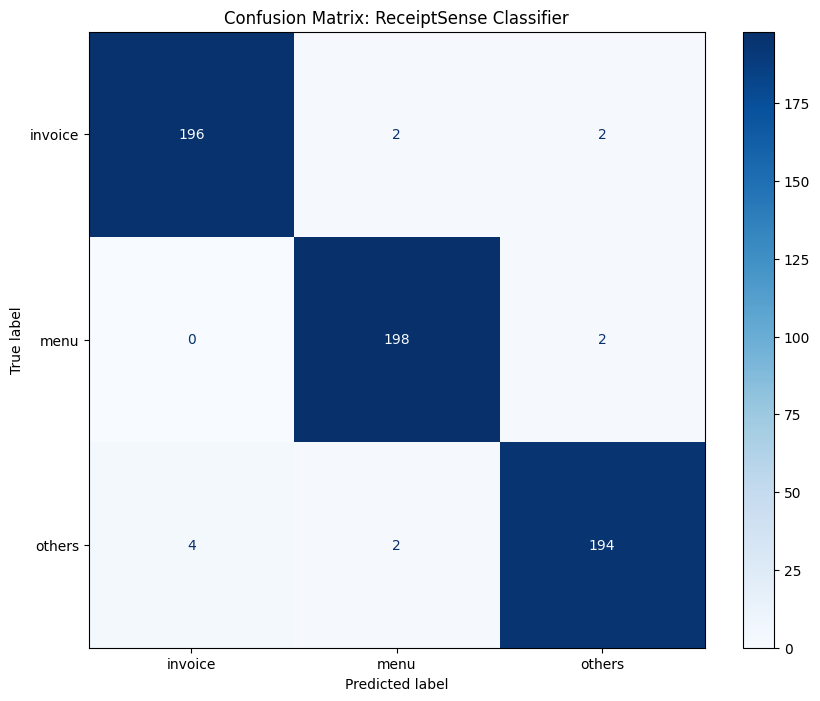

In [20]:
test_loader = DataLoader(image_datasets['test'], batch_size=6, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

all_preds = []
all_labels = []

print("📊 Testing the model and collecting results...")

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

class_names = image_datasets['test'].classes

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')

plt.title('Confusion Matrix: ReceiptSense Classifier')
plt.show()

In [115]:
path = r'Enter your path'
predict_all_images(model, path)

🚀 تم العثور على 33 صور. جاري التنبؤ...

Image Name                               | Prediction      | Confidence
---------------------------------------------------------------------------
crop_0_0.jpg                             | Others          | 99.77%
crop_0_1.jpg                             | Others          | 99.64%
crop_0_2.jpg                             | Others          | 99.88%
crop_0_3.jpg                             | Others          | 99.84%
crop_0_4.jpg                             | Menu            | 71.30%
crop_0_5.jpg                             | Menu            | 62.10%
crop_0_6.jpg                             | Others          | 77.96%
crop_0_7.jpg                             | Menu            | 56.84%
crop_0_8.jpg                             | Others          | 54.49%
Invoice 1.jpg                            | Invoice         | 99.87%
Invoice 10.webp                          | Invoice         | 83.31%
Invoice 11.webp                          | Invoice         | 81.

# YOLO

In [39]:
def predict_all_images(Model, directory_path='.'):

    transform = transforms.Compose([
        transforms.Resize((448, 448)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    valid_extensions = ('.jpg', '.jpeg', '.png', '.gif', '.bmp', '.webp', '.tif')
    image_files = [f for f in os.listdir(directory_path) 
                   if f.lower().endswith(valid_extensions)]

    if not image_files:
        print(f"❌ لم يتم العثور على صور في المجلد: {directory_path}")
        return

    class_names = Model.names if hasattr(Model, 'names') else {0: 'Invoice', 1: 'Menu', 2: 'Others'}
    
    stats = {name: 0 for name in class_names.values()}
    errors = 0

    print(f"🚀 تم العثور على {len(image_files)} صور. جاري التنبؤ...\n")
    print(f"{'Image Name':<40} | {'Prediction':<15} | {'Confidence'}")
    print("-" * 75)

    Model.eval()

    for img_name in image_files:
        try:
            img_path = os.path.join(directory_path, img_name)
            
            results = Model(img_path, verbose=False) 
            
            result = results[0] 

            if hasattr(result, 'probs') and result.probs is not None:
                top1_idx = result.probs.top1
                confidence_score = result.probs.top1conf.item() * 100
                label = class_names[top1_idx]
            else:
                output = result.orig_img 
                raise AttributeError("النموذج لم يعد احتمالات تصنيف. تأكد أنه Classification Model.")

            stats[label] += 1
            print(f"{img_name:<40} | {label:<15} | {confidence_score:.2f}%")
        
        except Exception as e:
            errors += 1
            print(f"{img_name:<40} | ❌ Error: {str(e)}")

    print("\n" + "="*40)
    print("📊 الإحصائية النهائية للتصنيف:")
    print("="*40)
    total_processed = len(image_files) - errors
    for category, count in stats.items():
        percentage = (count / total_processed * 100) if total_processed > 0 else 0
        print(f"🔹 {category:<10}: {count:>5} صور ({percentage:.1f}%)")
    
    if errors > 0:
        print(f"⚠️ أخطاء برمجية في {errors} ملفات")
    print("="*40)

In [47]:
from ultralytics import YOLO
last_model_path = r'Invoice_Classification\runs\classify\train7\weights\best.pt'

model = YOLO(last_model_path)
predict_all_images(model, path)

🚀 تم العثور على 33 صور. جاري التنبؤ...

Image Name                               | Prediction      | Confidence
---------------------------------------------------------------------------


C:\Users\aa\anaconda3\envs\gpu_env\lib\site-packages\torch\nn\modules\conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ..\aten\src\ATen\native\cudnn\Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,


crop_0_0.jpg                             | non_receipt     | 92.82%
crop_0_1.jpg                             | non_receipt     | 100.00%
crop_0_2.jpg                             | non_receipt     | 100.00%
crop_0_3.jpg                             | non_receipt     | 99.89%
crop_0_4.jpg                             | non_receipt     | 97.89%
crop_0_5.jpg                             | non_receipt     | 95.14%
crop_0_6.jpg                             | non_receipt     | 97.43%
crop_0_7.jpg                             | non_receipt     | 95.35%
crop_0_8.jpg                             | non_receipt     | 94.91%
Invoice 1.jpg                            | receipt         | 90.98%
Invoice 10.webp                          | receipt         | 100.00%
Invoice 11.webp                          | non_receipt     | 78.83%
Invoice 12.webp                          | receipt         | 99.70%
Invoice 13.webp                          | receipt         | 98.69%
Invoice 14.jpg                           | re

In [72]:
import torch
from ultralytics import YOLO
from PIL import Image
import time
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

last_model_path = r'Invoice_Classification\runs\classify\train7\weights\best.pt'
model = YOLO(last_model_path)

img_path = "Enter name of your image" 

if not os.path.exists(img_path):
    print(f"❌ خطأ: لم يتم العثور على الصورة في: {img_path}")
else:
    _ = model(img_path, verbose=False)
    
    start_time = time.time()
    
    results = model(img_path, verbose=False)
    
    end_time = time.time()
    latency = (end_time - start_time) * 1000

    result = results[0]
    
    if result.probs is not None:
        top1_idx = result.probs.top1
        conf_score = result.probs.top1conf.item() * 100
        label = model.names[top1_idx] 
        
        print(f"✅ Prediction: {label}")
        print(f"📊 Confidence: {conf_score:.2f}%")
        print(f"⚡ Latency: {latency:.2f} ms")
    else:
        print("⚠️ لم يتم العثور على نتائج تصنيف.")

✅ Prediction: receipt
📊 Confidence: 100.00%
⚡ Latency: 52.86 ms


## تحويل الصور لرمادي

In [18]:
def process_folder(folder_path, percentage=0.9):
    images = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    num_to_convert = int(len(images) * percentage)
    
    images_to_convert = random.sample(images, num_to_convert)
    
    print(f"جاري معالجة المجلد: {folder_path}")
    print(f"سيتم تحويل {len(images_to_convert)} صورة من أصل {len(images)}...")

    for img_name in images_to_convert:
        img_path = os.path.join(folder_path, img_name)
        
        img = cv2.imread(img_path)
        
        if img is not None:
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            
            cv2.imwrite(img_path, gray)

train_receipts = r'Dataset\train\receipt'
val_receipts = r'Dataset\val\receipt'

process_folder(train_receipts, percentage=0.9)
process_folder(val_receipts, percentage=0.9)

print("اكتملت العملية بنجاح!")

جاري معالجة المجلد: E:\مجلد جديد\Invoice\Dataset\train\receipt
سيتم تحويل 900 صورة من أصل 1000...
جاري معالجة المجلد: E:\مجلد جديد\Invoice\Dataset\val\receipt
سيتم تحويل 180 صورة من أصل 200...
اكتملت العملية بنجاح!


## تدريب yolo

In [ ]:
if not hasattr(cv2, 'imdecodemulti'):
    print("تنبيه: دالة imdecodemulti غير موجودة، يتم إنشاء بديل يدوي...")
    def imdecodemulti_patch(buf, flags):
        img = cv2.imdecode(buf, flags)
        if img is None:
            return False, []
        return True, [img]
    cv2.imdecodemulti = imdecodemulti_patch

from ultralytics import YOLO

model = YOLO('yolo11l-cls.pt') 

results = model.train(
    data='Dataset',
    epochs=7,
    imgsz=448,
    batch=4,         
    workers=0,        
    device=0,
    #half=True
)

تنبيه: دالة imdecodemulti غير موجودة، يتم إنشاء بديل يدوي...
Ultralytics 8.4.12  Python-3.10.19 torch-2.3.0+cu118 CUDA:0 (NVIDIA GeForce GTX 1050, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Dataset, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=7, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=448, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11l-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train9, nbs=64, nms=False, opset=None, optimize=False, optimizer

C:\Users\aa\anaconda3\envs\gpu_env\lib\site-packages\torch\nn\modules\conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ..\aten\src\ATen\native\cudnn\Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,


AMP: checks passed 
train: Fast image access  (ping: 0.10.0 ms, read: 1607.4568.1 MB/s, size: 1279.8 KB)
train: Scanning E:\مجلد جديد\Invoice\Dataset\train... 3395 images, 0 corrupt: 100% ━━━━━━━━━━━━ 3395/3395 488.2it/s 7.0s.6ss
train: New cache created: E:\ \Invoice\Dataset\train.cache
val: Fast image access  (ping: 9.113.2 ms, read: 32.016.6 MB/s, size: 1158.0 KB)
val: Scanning E:\مجلد جديد\Invoice\Dataset\val... 600 images, 0 corrupt: 100% ━━━━━━━━━━━━ 600/600 143.3it/s 4.2s<0.0s
val: New cache created: E:\ \Invoice\Dataset\val.cache
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001429, momentum=0.9) with parameter groups 82 weight(decay=0.0), 83 weight(decay=0.0005), 83 bias(decay=0.0)
Image sizes 448 train, 448 val
Using 0 dataloader workers
Logging results to E:\ \Invoice\runs\classify\train9
Starting training for 7 epochs...

      Epoch    GPU_mem       

C:\Users\aa\anaconda3\envs\gpu_env\lib\site-packages\torch\autograd\graph.py:744: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ..\aten\src\ATen\native\cudnn\Conv_v8.cpp:919.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


        1/7      1.17G      1.229          4        448: 4% ──────────── 30/849 1.1it/s 37.7s<12:55

In [ ]:
if not hasattr(cv2, 'imdecodemulti'):
    def imdecodemulti_patch(buf, flags):
        img = cv2.imdecode(buf, flags)
        return (True, [img]) if img is not None else (False, [])
    cv2.imdecodemulti = imdecodemulti_patch

last_model_path = r'Invoice_Classification\runs\classify\train7\weights\last.pt'

model = YOLO(last_model_path)

model.train(resume=True)